<a href="https://colab.research.google.com/github/Pheonix1795/MDS_LAB/blob/main/MDS_WEEK(12%2C13)II.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Load the Dataset
We will use the `datasets` library to load `maxfactor71/house_pricing` and convert it into a Pandas DataFrame for easy analysis.

In [1]:
from datasets import load_dataset
import pandas as pd

# Load the dataset from Hugging Face
ds = load_dataset("maxfactor71/house_pricing")

# Convert to pandas DataFrame (assuming the 'train' split exists)
df = pd.DataFrame(ds['train'])
display(df.head())

(…)e_price_regression_dataset%20%281%29.csv:   0%|          | 0.00/54.8k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


### 2. Visualize Data using Various Plots
We will now generate the requested visualizations: Line Plots, Bar Plots, Histograms, Density Plots, and Scatter Plots using `matplotlib` and `seaborn`.

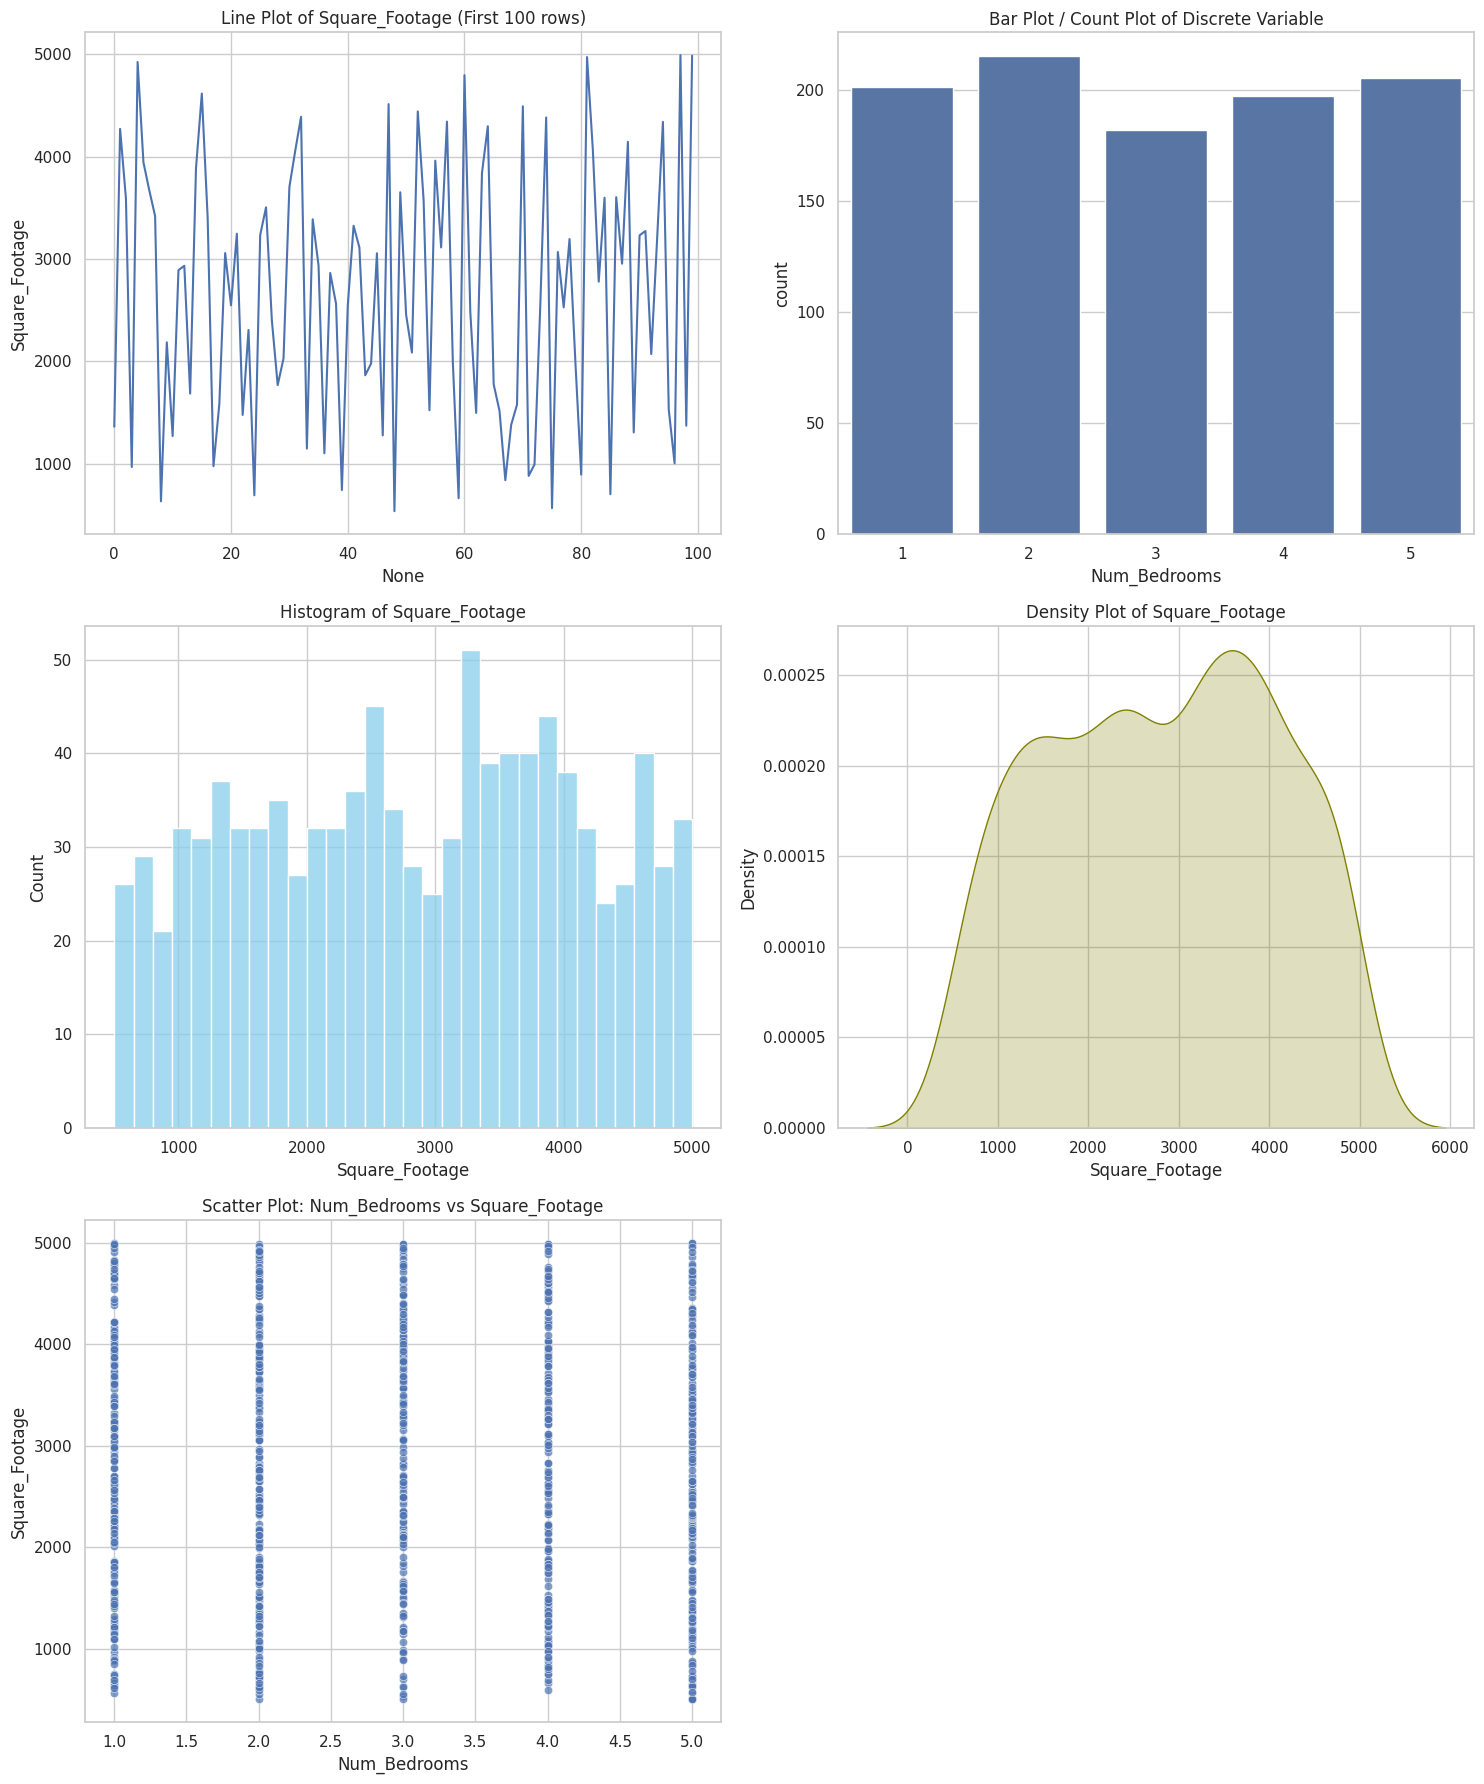

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set seaborn aesthetic style
sns.set_theme(style="whitegrid")

# Select numeric columns for plotting
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Create a multi-plot figure
fig, axes = plt.subplots(3, 2, figsize=(15, 18))

# 1. Line Plot (e.g., trend of price if any sequential/index structure exists)
if len(num_cols) > 0:
    sns.lineplot(ax=axes[0, 0], data=df.head(100), y=num_cols[0], x=df.head(100).index)
    axes[0, 0].set_title(f'Line Plot of {num_cols[0]} (First 100 rows)')

# 2. Bar Plot (Value counts of a categorical variable or average numerical feature per category)
if len(cat_cols) > 0 and len(num_cols) > 0:
    sns.barplot(ax=axes[0, 1], data=df, x=cat_cols[0], y=num_cols[0], errorbar=None)
    axes[0, 1].set_title(f'Average {num_cols[0]} by {cat_cols[0]}')
    axes[0, 1].tick_params(axis='x', rotation=45)
else:
    # Fallback bar plot of value counts of a discrete feature
    sns.countplot(ax=axes[0, 1], data=df, x=num_cols[1] if len(num_cols) > 1 else num_cols[0])
    axes[0, 1].set_title('Bar Plot / Count Plot of Discrete Variable')

# 3. Histogram
if len(num_cols) > 0:
    sns.histplot(ax=axes[1, 0], data=df, x=num_cols[0], bins=30, kde=False, color='skyblue')
    axes[1, 0].set_title(f'Histogram of {num_cols[0]}')

# 4. Density Plot
if len(num_cols) > 0:
    sns.kdeplot(ax=axes[1, 1], data=df, x=num_cols[0], fill=True, color='olive')
    axes[1, 1].set_title(f'Density Plot of {num_cols[0]}')

# 5. Scatter Plot
if len(num_cols) > 1:
    sns.scatterplot(ax=axes[2, 0], data=df, x=num_cols[1], y=num_cols[0], alpha=0.7)
    axes[2, 0].set_title(f'Scatter Plot: {num_cols[1]} vs {num_cols[0]}')

# Remove empty subplot if we don't have enough configurations
fig.delaxes(axes[2, 1])

plt.tight_layout()
plt.show()

### 3. Check Skewness and Remove It
Highly skewed target variables (like House Prices) or features can destabilize model performance. We will evaluate the skewness of a numeric column and apply a Log Transformation to reduce/remove its skewness.

Original Skewness of 'Square_Footage': -0.0659
Skewness after Log Transformation: -0.8697


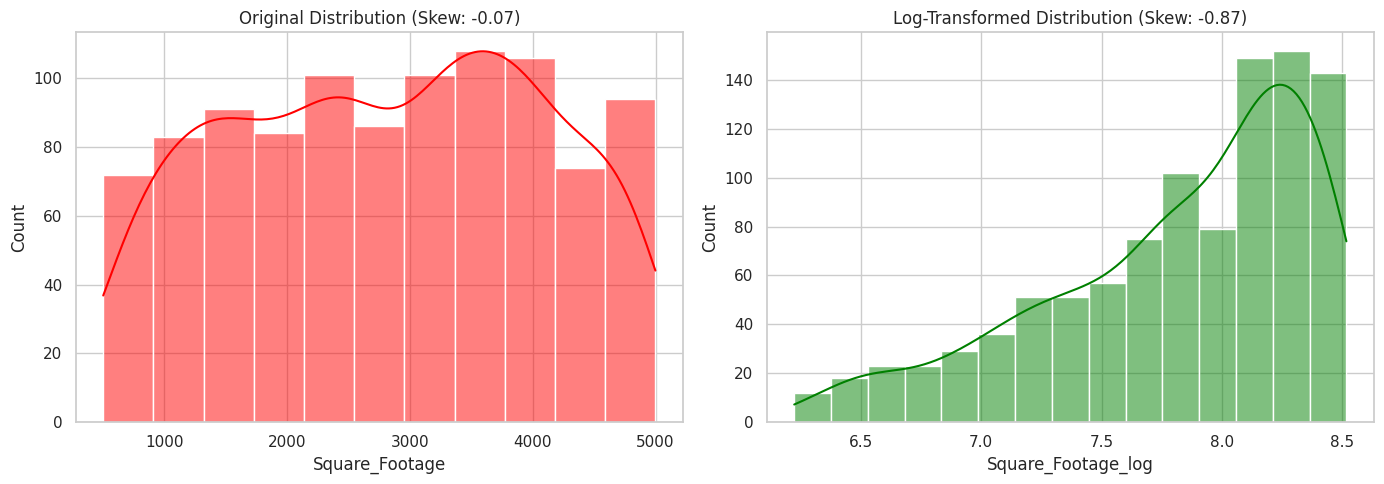

In [3]:
from scipy.stats import skew

# Identify a highly skewed numeric column (usually target column like price)
target_col = num_cols[0] if len(num_cols) > 0 else df.columns[0]
original_skew = skew(df[target_col].dropna())
print(f"Original Skewness of '{target_col}': {original_skew:.4f}")

# Apply Log Transformation (log1p handles 0 values safely)
df[f'{target_col}_log'] = np.log1p(df[target_col])
transformed_skew = skew(df[f'{target_col}_log'].dropna())
print(f"Skewness after Log Transformation: {transformed_skew:.4f}")

# Plot the comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df[target_col], kde=True, ax=axes[0], color='red')
axes[0].set_title(f'Original Distribution (Skew: {original_skew:.2f})')

sns.histplot(df[f'{target_col}_log'], kde=True, ax=axes[1], color='green')
axes[1].set_title(f'Log-Transformed Distribution (Skew: {transformed_skew:.2f})')

plt.tight_layout()
plt.show()

### 4. Visualizing with Different Color Scales
Here we will showcase the dataset using different colormaps like `viridis`, `plasma`, `coolwarm`, and `YlOrRd` to demonstrate how color palettes can be customized.

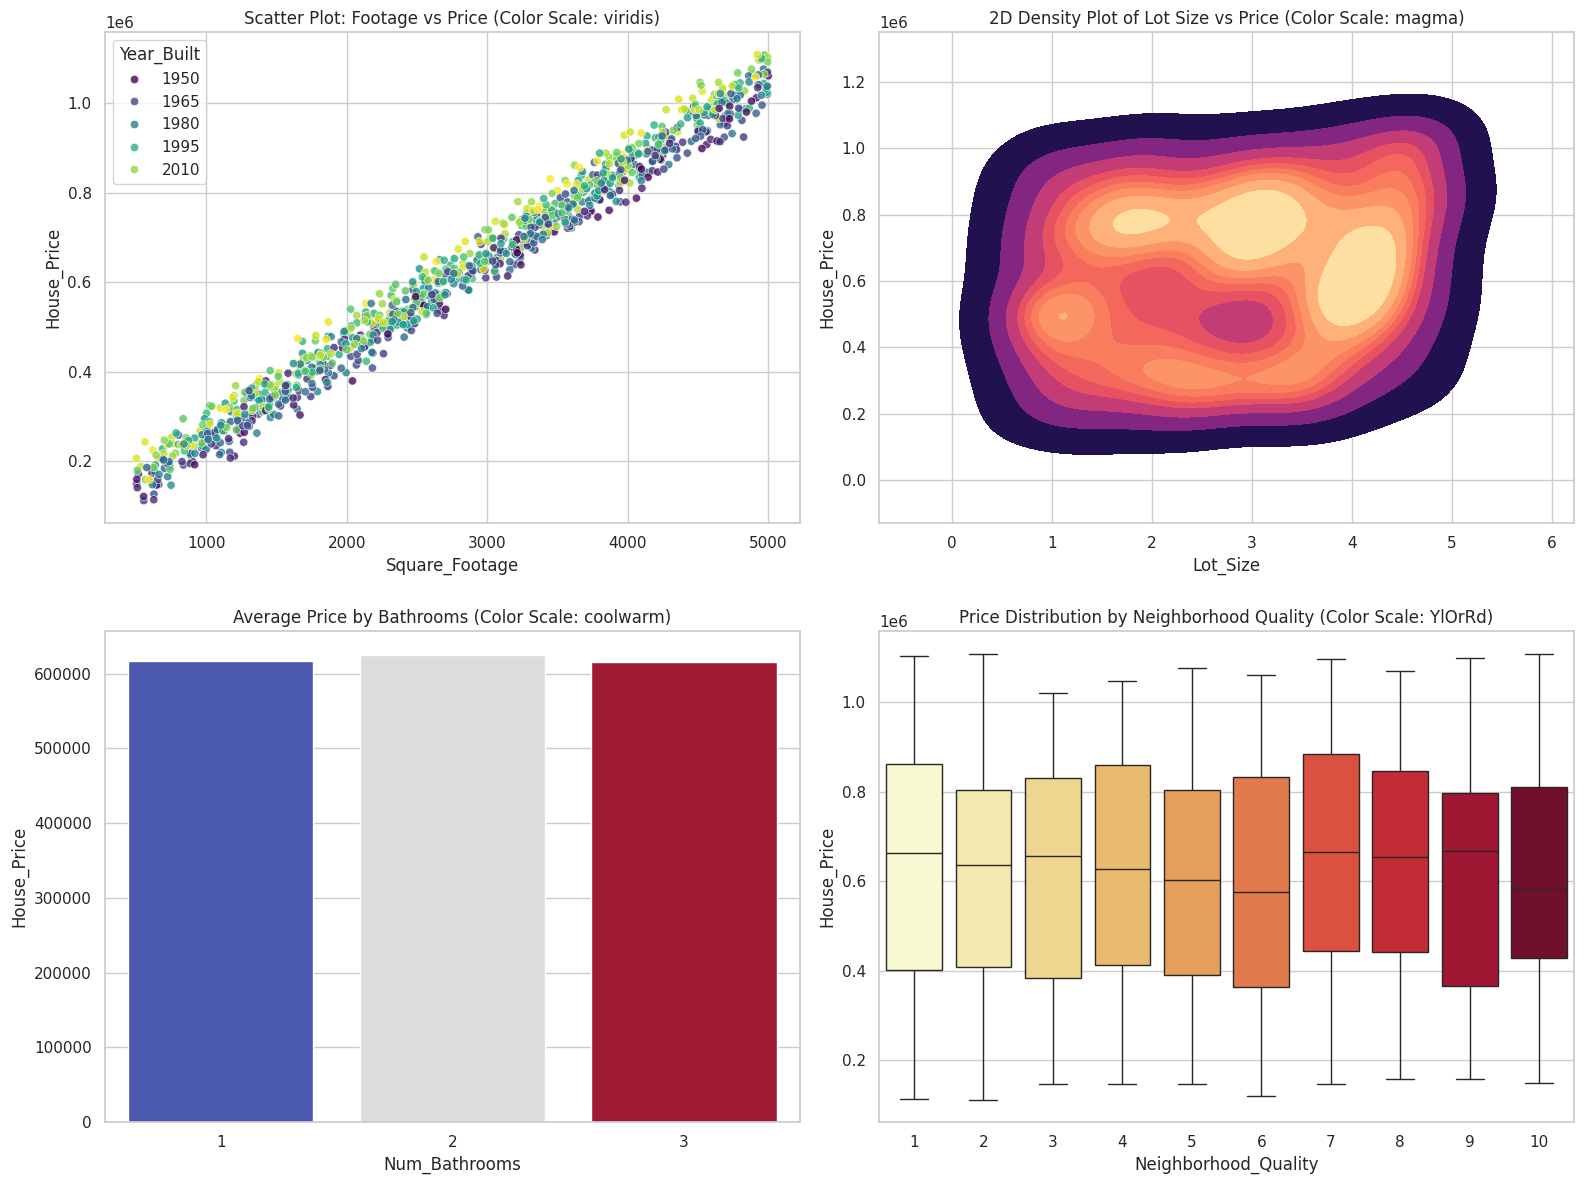

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Scatter Plot with 'viridis' color scale mapped to Year_Built
sns.scatterplot(ax=axes[0, 0], data=df, x='Square_Footage', y='House_Price', hue='Year_Built', palette='viridis', alpha=0.8)
axes[0, 0].set_title('Scatter Plot: Footage vs Price (Color Scale: viridis)')

# 2. Hexbin joint plot equivalent / 2D Density with 'magma'
sns.kdeplot(ax=axes[0, 1], data=df, x='Lot_Size', y='House_Price', cmap='magma', fill=True, thresh=0.05)
axes[0, 1].set_title('2D Density Plot of Lot Size vs Price (Color Scale: magma)')

# 3. Bar Plot with 'coolwarm' palette
sns.barplot(ax=axes[1, 0], data=df, x='Num_Bathrooms', y='House_Price', palette='coolwarm', hue='Num_Bathrooms', legend=False, errorbar=None)
axes[1, 0].set_title('Average Price by Bathrooms (Color Scale: coolwarm)')

# 4. Box Plot with 'YlOrRd' palette
sns.boxplot(ax=axes[1, 1], data=df, x='Neighborhood_Quality', y='House_Price', palette='YlOrRd', hue='Neighborhood_Quality', legend=False)
axes[1, 1].set_title('Price Distribution by Neighborhood Quality (Color Scale: YlOrRd)')

plt.tight_layout()
plt.show()

### 5. Advanced Exploration with Diverse Color Scales
We will showcase different color scale families to visualize relationships within the house pricing dataset:
- **Continuous/Sequential (`viridis`)**: Excellent for representing continuous numerical ranges with uniform perceptual brightness.
- **Diverging (`coolwarm`)**: Ideal for highlighting deviations from a central baseline or comparing binary/polarizing groups.
- **Sequential Dark (`magma`)**: A high-impact palette highlighting peak density regions.
- **Cubehelix (`cubehelix`)**: A specialized color scheme designed to degrade gracefully to grayscale while remaining visually attractive.

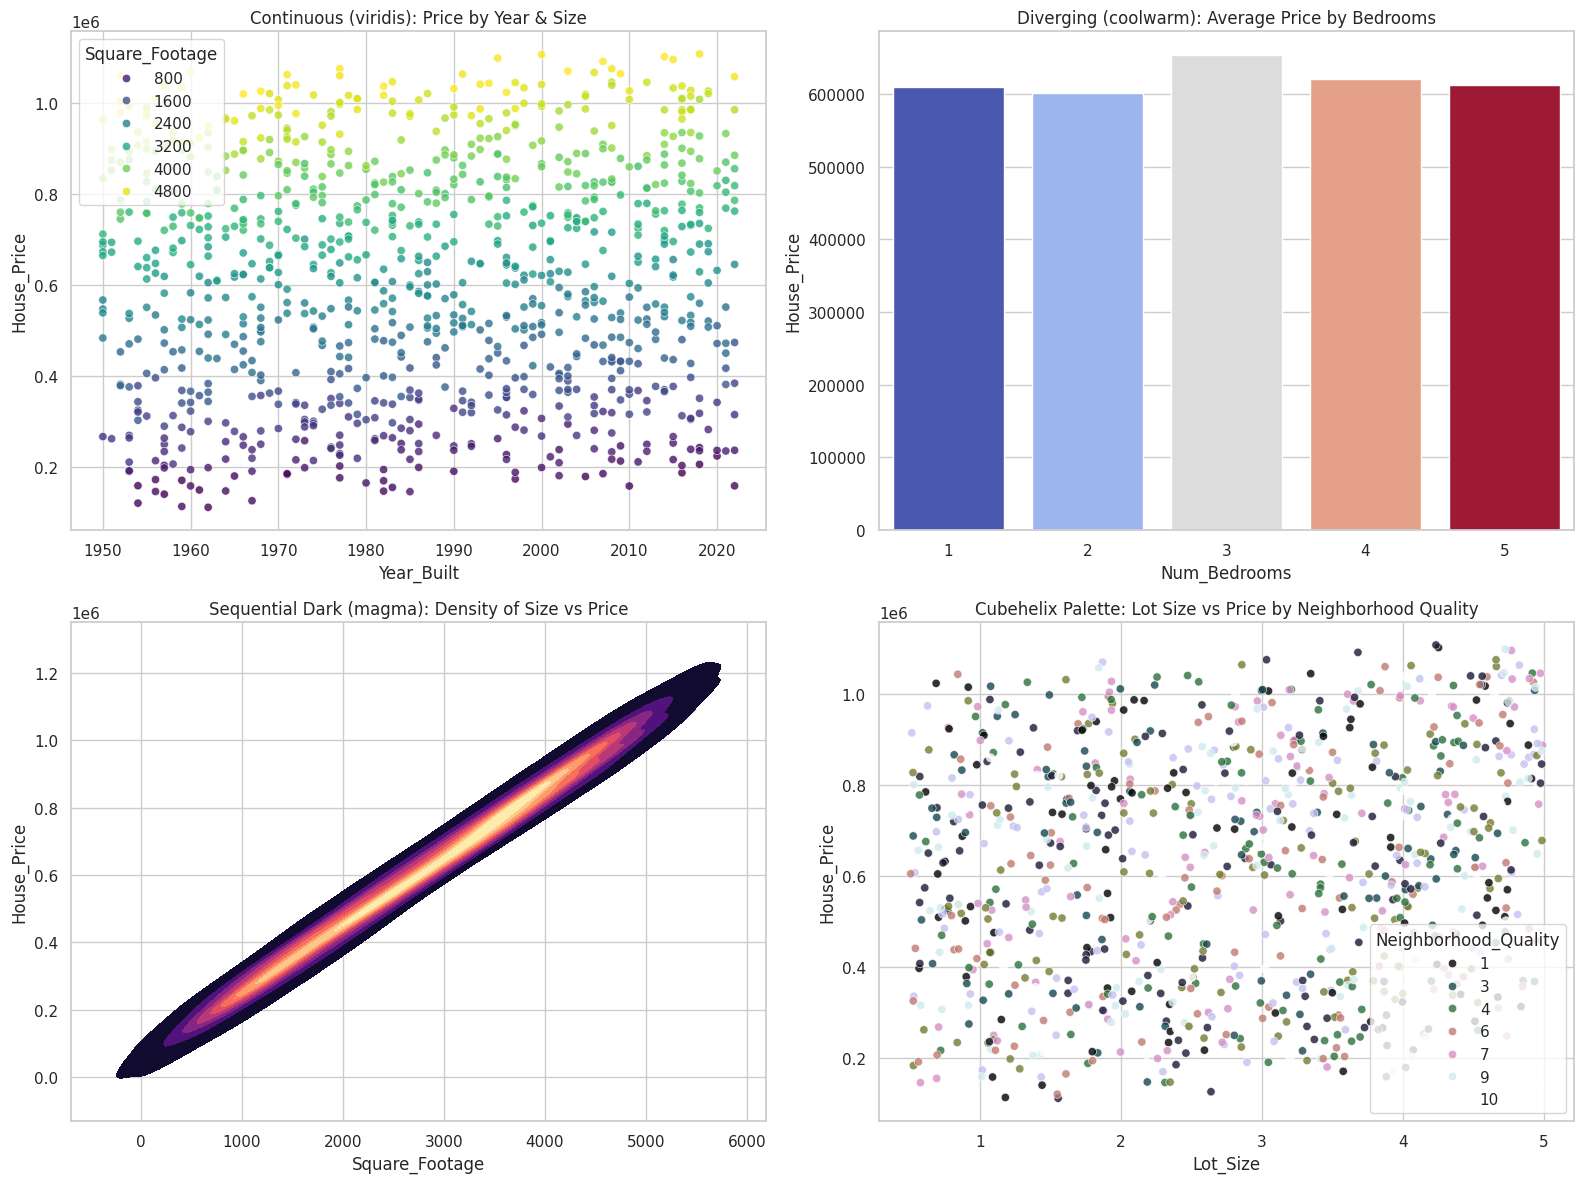

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Continuous (viridis) - Visualizing Year Built vs House Price with continuous Square Footage
sns.scatterplot(ax=axes[0, 0], data=df, x='Year_Built', y='House_Price', hue='Square_Footage', palette='viridis', alpha=0.8)
axes[0, 0].set_title('Continuous (viridis): Price by Year & Size')

# 2. Diverging (coolwarm) - Average House Price by Number of Bedrooms
# Grouping and coloring to demonstrate high vs low deviations
sns.barplot(ax=axes[0, 1], data=df, x='Num_Bedrooms', y='House_Price', palette='coolwarm', hue='Num_Bedrooms', legend=False, errorbar=None)
axes[0, 1].set_title('Diverging (coolwarm): Average Price by Bedrooms')

# 3. Sequential Dark (magma) - 2D density of Footage vs House Price
sns.kdeplot(ax=axes[1, 0], data=df, x='Square_Footage', y='House_Price', cmap='magma', fill=True, thresh=0.01)
axes[1, 0].set_title('Sequential Dark (magma): Density of Size vs Price')

# 4. Cubehelix - Scatter plot of Lot Size vs House Price colored by Neighborhood Quality
sns.scatterplot(ax=axes[1, 1], data=df, x='Lot_Size', y='House_Price', hue='Neighborhood_Quality', palette='cubehelix', alpha=0.8)
axes[1, 1].set_title('Cubehelix Palette: Lot Size vs Price by Neighborhood Quality')

plt.tight_layout()
plt.show()